In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from pathlib import Path
from scipy.special import rel_entr, kl_div
from scipy.stats import wasserstein_distance
import h5py

plt.rcParams.update({'font.size': 14}) 

PARAMETERS = ['cpa', 'pwr1par', 'pwr1perr', 'pwr2par', 'pwr2perr'] 
PARAMETERS_NAME = [r'$k^{0}_{\parallel}$', r'$a_{\parallel}$', r'$a_{\perp}$', r'$b_{\parallel}$', r'$b_{\perp}$'] 
PARAMETERS_MIN = np.array([100., 0.4, 0.4, 0.4, 0.4]) 
PARAMETERS_MAX = np.array([870., 1.7, 1.7, 2.3, 2.3]) 

# Hardcoded model choices.
INPUTS = ['alpha', 'cmf', 'cpa', 'pwr1par', 'pwr1perr', 'pwr2par', 'pwr2perr', 'vspoles']
# These are hardcoded for transforms. Used in both parities.
X_MIN = np.array([0.,  2.5, 100., 0.4, 0.4, 0.4, 0.4, 400.]) 
X_MAX = np.array([85., 9.5, 870., 1.7, 1.7, 2.3, 2.3, 700.])
X_RANGE = np.array([ 85., 7., 770., 1.3000001, 1.3000001, 1.9, 1.9, 300.])
# X_MIN,X_MAX,X_RANGE = get_minmax_params(get_attributes(infile))
# These are selected from above and hardcoded.
PARAMETERS = ['cpa', 'pwr1par', 'pwr1perr', 'pwr2par', 'pwr2perr'] 
PARAMETERS_MIN = np.array([100., 0.4, 0.4, 0.4, 0.4]) 
PARAMETERS_MAX = np.array([870., 1.7, 1.7, 2.3, 2.3]) 
# These parameter don't include (alpha, cmf, vspoles) which we specify separately.
PARAMETERS_SPECIFIED = ['alpha', 'cmf', 'vspoles']
PARAMETERS_SPECIFIED_MIN = np.array([0.,  2.5, 400.])
PARAMETERS_SPECIFIED_MAX = np.array([85., 9.5, 700.])

data_version=['d1', 'd2', 'd3', 'd4', 'd5'] 
model_version=['init1', 'init2', 'init3', 'init4', 'init5'] 
hmc_run = ['hmc1', 'hmc2', 'hmc3', 'hmc4', 'hmc5']
bootstrap=['b0', 'b1'] # 'b0' or 'b1', false or true
which_changes = ["bootstrapped_data", "no_bootstrap"] 
train_size_fractions = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
valid_interval_indices = [2, 79, 87, 103, 104, 128, 129, 146, 170, 175, 212, 235, 263, 311, 312, 337, 346, 358, 373, 403, 423, 434, 481, 484, 496, 519, 526, 528, 531, 549, 569, 579, 613, 616, 627, 645, 660, 668, 699, 707, 715, 739, 746, 777, 810, 859, 869, 917, 953, 1003, 1023, 1054, 1063, 1093, 1116, 1140, 1141, 1161, 1206, 1218, 1238, 1249, 1267, 1273, 1277, 1279, 1311, 1315, 1349, 1354, 1375, 1394, 1407, 1414, 1432, 1464, 1475, 1477, 1540, 1551, 1589, 1648, 1695, 1761, 1776, 1781, 1846, 1908, 1914, 1949, 1981, 1998, 2035, 2042, 2056, 2127, 2145, 2160, 2188, 2194]
hmc_versions=['prior_experiment_v34_trial5_ppc_10000_interpolated_test_pamela_sampled_False']
num_bins = 30
file_version = 'test_data' # 'test_data' or '2023'

## Relevant functions from utils.py
Can't just import utils since path to data is different than utils.py

In [30]:
def index_mcmc_runs(file_version):
    """Make a list of combinations for which we want to run MCMC."""
    if file_version == '2023':
        experiments = ['AMS02_H-PRL2021', 'PAMELA_H-ApJ2013', 'PAMELA_H-ApJL2018']
        dfs = []
        for experiment_name in experiments:
            filename = f'../../data/2023/{experiment_name}_heliosphere.dat'
            df = index_experiment_files(filename) 
            df['experiment_name'] = experiment_name
            df['filename_heliosphere'] = filename
            dfs.append(df)
        df = pd.concat(dfs, axis=0, ignore_index=0)

    elif file_version == '2024':
        filename = f'../../data/2024/yearly_heliosphere.dat'
        df = read_experiment_summary(filename)
        df['experiment_name'] = 'yearly'
        df['filename_heliosphere'] = filename

    else: raise ValueError(f"Unknown file_version {file_version}. Must be '2023' or '2024'.")

    return df

def read_experiment_summary(filename) -> pd.DataFrame:
    """
    Read .dat filename that describes experimental conditions during time intervals.
    """
    if '2023' in filename: file_version = '2023'
    elif '2024' in filename: file_version = '2024'
    else: raise ValueError(f"Unknown file_version {file_version}. Must be '2023' or '2024'.")

    if file_version == '2023':
        # Header reads "time interval; alpha avg; cmf avg; vspoles avg; alpha std; cmf std; vspoles std"
        df = pd.read_csv(filename, sep=' ', skiprows=1, names=['interval', 'alpha', 'cmf', 'vspoles', 'alpha_std', 'cmf_std', 'vspoles_std'])
    
        # Parse interval
        df['beginning'] = df.interval.apply(lambda x: pd.to_datetime(x.split('-')[0], format='%Y%m%d'))
        df['ending'] = df.interval.apply(lambda x: pd.to_datetime(x.split('-')[0], format='%Y%m%d'))

    elif file_version == '2024':
        # Header reads "time interval; alpha avg; cmf avg; vspoles avg; alpha std; cmf std; vspoles std; polarity"
        df_full = pd.read_csv(filename, sep=' ', skiprows=1, names=['interval', 'alpha', 'cmf', 'vspoles', 'alpha_std', 'cmf_std', 'vspoles_std', 'polarity'])

        # only use the neg or neg,pos polarities column, and change all to be neg
        df = df_full[df_full['polarity'].str.contains('neg')].copy(deep=True)
        df['polarity'] = 'neg'

    return df

def index_experiment_files(filename)->pd.DataFrame:
    """Create list of experiments that need to be done. 
    Note this is only needed for file_version '2023'
    filename = f'../../data/2023/{EXPERIMENT_NAME}_heliosphere.dat'
    """
    df = read_experiment_summary(filename)
    # The datasets to be fitted are: PAMELA_H-ApJ2013, PAMELA_H-ApJL2018, and AMS02_H-PRL2021.
    # You should use the neg models for data files up to February 2015, and the pos models for data files from October 2013.
    # So, between October 2013 and February 2015, the data files should be fitted independently with both neg and pos models.
    # All PAMELA files are before February 2015, so only neg models for them.
    # For AMS02 files, 20130925-20131021.dat is the first file to be fitted with pos models, while 20150124-20150219.dat is the last file to be fitted with neg models.
    # 
    # For PAMELA_H-ApJL2018, the files 20130928-20131025.dat, 20131121-20131219.dat, and 20140115-20140211.dat should be fit independently with both neg and pos models.

    dfneg = df[df.beginning < pd.to_datetime('March 1 2015')].copy(deep=True)
    dfneg['polarity'] = 'neg'

    dfpos = df[df.ending >= pd.to_datetime('October 1 2013')].copy(deep=True)
    dfpos['polarity'] = 'pos'

    # rval = pd.concat([dfneg, dfpos], axis=0, ignore_index=True)
    rval = dfneg # Only fitting negative models for now.
    
    return rval

def _get_transform_params(X):
    """
    Helper function for calculating min max.
    """
    assert len(PARAMETERS) != len(PARAMETERS_SPECIFIED)
    input_dim = X.ndim
    if (X.ndim == 1 and len(X) == len(INPUTS)) or (X.ndim == 2 and X.shape[1] == len(INPUTS)):
        # Full set of inputs. 
        MIN, MAX = X_MIN, X_MAX
    elif ((X.ndim == 1 and len(X) == len(PARAMETERS)) or (X.ndim == 2 and X.shape[1] == len(PARAMETERS))):
        # Assume specified parameters have already been specified separately.
        MIN, MAX = PARAMETERS_MIN, PARAMETERS_MAX
    elif ((X.ndim == 1 and len(X) == len(PARAMETERS_SPECIFIED)) or (X.ndim == 2 and X.shape[1] == len(PARAMETERS_SPECIFIED))):
        # Assume other parameters have already been specified separately.
        MIN, MAX = PARAMETERS_SPECIFIED_MIN, PARAMETERS_SPECIFIED_MAX
    else:
        raise Exception
    return (MIN, MAX)
    

def transform_input(X):
    '''
    Parameters from HMC are all in min-max scaled space.
    This function tries to smartly handle case where some of the inputs are specified separately.
    '''
    MIN, MAX = _get_transform_params(X)
    RANGE = MAX - MIN
    rval = (X - MIN) / RANGE
    return rval


def untransform_input(X):
    '''
    Parameters from HMC are all in min-max scaled space.
    This function tries to smartly handle case where some of the inputs are specified separately.
    '''
    MIN, MAX = _get_transform_params(X)
    RANGE = MAX - MIN
    rval = X * RANGE + MIN
    return rval

def _as_array(x):
    """Get a float64 NumPy array from a pandas Series/array-like."""
    # Works for pandas Series (has .values) and plain np arrays/lists
    try:
        return np.asarray(x.values, dtype=float)
    except AttributeError:
        return np.asarray(x, dtype=float)

def _rhat_from_chains(chains_2d: np.ndarray,
                      ensure_ge1: bool = True,
                      return_details: bool = False):
    """
    Compute Gelman–Rubin R-hat from multiple chains following the 4-step description from 
    https://mystatisticsblog.blogspot.com/2019/04/gelman-rubin-convergence-criteria-for.html. 
    Assumes chains are already prepared (e.g., only second halves if that's your convention), 
    so that `chains_2d` has shape (m, n) with m = #chains and n = samples/chain.

    Steps implemented:
      1) (Warmup removal is assumed done before this function.)
      2) Per-chain mean & variance:  θ̄_j and σ²(θ_j)
      3) Mean-of-means θ̄̄, mean within-chain variance σ̄²(θ),
         variance of chain means σ²(θ̄)
         Then B_j = σ²(θ̄) − (1/n) σ̄²(θ)
      4) R̂ = sqrt( 1 + B_j / σ̄²(θ) )

    Also computes the classic equivalent:
      W = σ̄²(θ), B = n * σ²(θ̄),
      Var⁺ = ((n−1)/n) W + (B/n),
      R̂_classic = sqrt(Var⁺ / W)

    Args
    ----
    chains_2d : np.ndarray
        Shape (m, n): m chains, n samples per chain.
    ensure_ge1 : bool
        If True, clamp R-hat to be at least 1.0 (common practice).
    return_details : bool
        If True, return (rhat, details_dict). Otherwise return rhat (float).

    Returns
    -------
    rhat : float
    (optionally) details : dict with intermediate quantities
    """
    if chains_2d.ndim != 2:
        raise ValueError("chains_2d must have shape (m, n).")
    m, n = chains_2d.shape
    if m < 2 or n < 2:
        out = np.nan
        return (out, {}) if return_details else out

    # Step 2: per-chain means and variances (unbiased)
    theta_bar_j = chains_2d.mean(axis=1)             # θ̄_j
    sigma2_theta_j = chains_2d.var(axis=1, ddof=1)   # σ²(θ_j), unbiased

    # Step 3: across-chain aggregates
    theta_barbar = theta_bar_j.mean()                              # θ̄̄
    sigma2_bar_theta = sigma2_theta_j.mean()                       # σ̄²(θ) = W
    sigma2_theta_bar = theta_bar_j.var(ddof=1)                     # σ²(θ̄)
    B_j = sigma2_theta_bar - (sigma2_bar_theta / n)                # B_j

    # Step 4: scale reduction
    if sigma2_bar_theta <= 0:
        rhat = np.nan
    else:
        rhat = float(np.sqrt(1.0 + (B_j / sigma2_bar_theta)))

    # Optional clamp to ≥ 1
    if ensure_ge1 and np.isfinite(rhat):
        if rhat < 1.0:
            rhat = 1.0

    # Classic form (for verification / curiosity)
    W = sigma2_bar_theta
    B = n * sigma2_theta_bar
    var_plus = ((n - 1) / n) * W + (B / n)
    rhat_classic = float(np.sqrt(var_plus / W)) if W > 0 else np.nan

    if return_details:
        details = {
            "m": m, "n": n,
            "theta_bar_j": theta_bar_j,          # per-chain means
            "sigma2_theta_j": sigma2_theta_j,    # per-chain variances
            "theta_barbar": theta_barbar,        # mean of means
            "sigma2_bar_theta": sigma2_bar_theta,# mean within-chain var (W)
            "sigma2_theta_bar": sigma2_theta_bar,# variance of chain means
            "B_j": B_j,
            "W": W, "B": B, "var_plus": var_plus,
            "rhat_equation_form": rhat,
            "rhat_classic_equivalent": rhat_classic
        }
        return rhat, details
    else:
        return rhat

def compute_rhat(
    chains_samples,
    params=PARAMETERS,
    mode: str = "split",   # "split" or "last_half"
    thin: int = 1,
    return_details: bool = False
):
    """
    Compute R-hat for each parameter across multiple HMC chains.

    Args:
      chains_samples: list of dict[param -> pd.Series/np.ndarray]
      params: list of parameter names to compute.
      mode:
        - "split": split each chain into two halves → shape (2*#chains, N/2)
        - "last_half": keep only the second half of each chain → shape (#chains, N/2)
      thin: keep every 'thin'-th sample (applied after halving/splitting prep)

    Returns:
      dict[param -> rhat_value]
    """
    assert mode in {"split", "last_half"}, "mode must be 'split' or 'last_half'"
    rhats = {}

    for p in params:
        segments = []  # list of 1D arrays to be stacked into (m, n)

        # Build per-chain segments according to the selected mode
        for ch in chains_samples:
            if p not in ch:
                continue
            x = _as_array(ch[p])
            if x.size < 4:
                continue  # too short to halve/split sensibly

            n = x.size
            half = n // 2

            if mode == "last_half":
                seg = x[half:]              # keep only the second half
                seg = seg[::thin]           # thin
                if seg.size >= 2:
                    segments.append(seg)

            elif mode == "split":
                first = x[:half]
                second = x[-half:]
                first = first[::thin]
                second = second[::thin]
                if first.size >= 2:
                    segments.append(first)
                if second.size >= 2:
                    segments.append(second)

        # Need at least 2 (sub)chains total
        if len(segments) < 2:
            rhats[p] = np.nan
            continue

        # Align lengths across segments
        segment_lengths = [len(s) for s in segments]
        n_min = np.min(segment_lengths)
        if n_min < 2:
            rhats[p] = np.nan
            continue

        chains_2d = np.stack([s[:n_min] for s in segments])  # shape (m, n_min)
        rhats[p] = _rhat_from_chains(chains_2d, return_details=return_details)

    return rhats

def get_distance(hist_0, hist_1, metric='mae'):
    """
    Compute distance between two histograms.
    """
    num_bins = len(hist_0)
    if len(hist_1) != num_bins:
        raise ValueError(f"Histograms must have the same number of bins. {len(hist_0)} != {len(hist_1)}")
    
    if metric == 'mae':
        return np.abs(hist_0 - hist_1).sum() / num_bins
    elif metric == 'mse':
        return ((hist_0 - hist_1) ** 2).sum() / num_bins
    elif metric == 'kl':
        return kl_div(hist_0, hist_1).sum()
    elif metric == 'wasserstein':
        return wasserstein_distance(hist_0, hist_1)
    else:
        raise ValueError(f"Unknown metric {metric}.")

def histogram_log_prob(value, hist, bin_edges):
    idx = np.digitize(value, bin_edges) - 1
    if idx < 0 or idx >= len(hist):
        return -np.inf
    width = bin_edges[idx+1] - bin_edges[idx]
    prob = hist[idx] * width   # mass, since hist is a density
    return np.log(prob) if prob > 0 else -np.inf

## Prior Experiment

Randomly selected index to plot: 1349
Saving to ../../../results/prior_experiment/v34_trial5_ppc_10000_interpolated_test_pamela_sampled_False/plots/ppc_log_prob_priors.csv? False


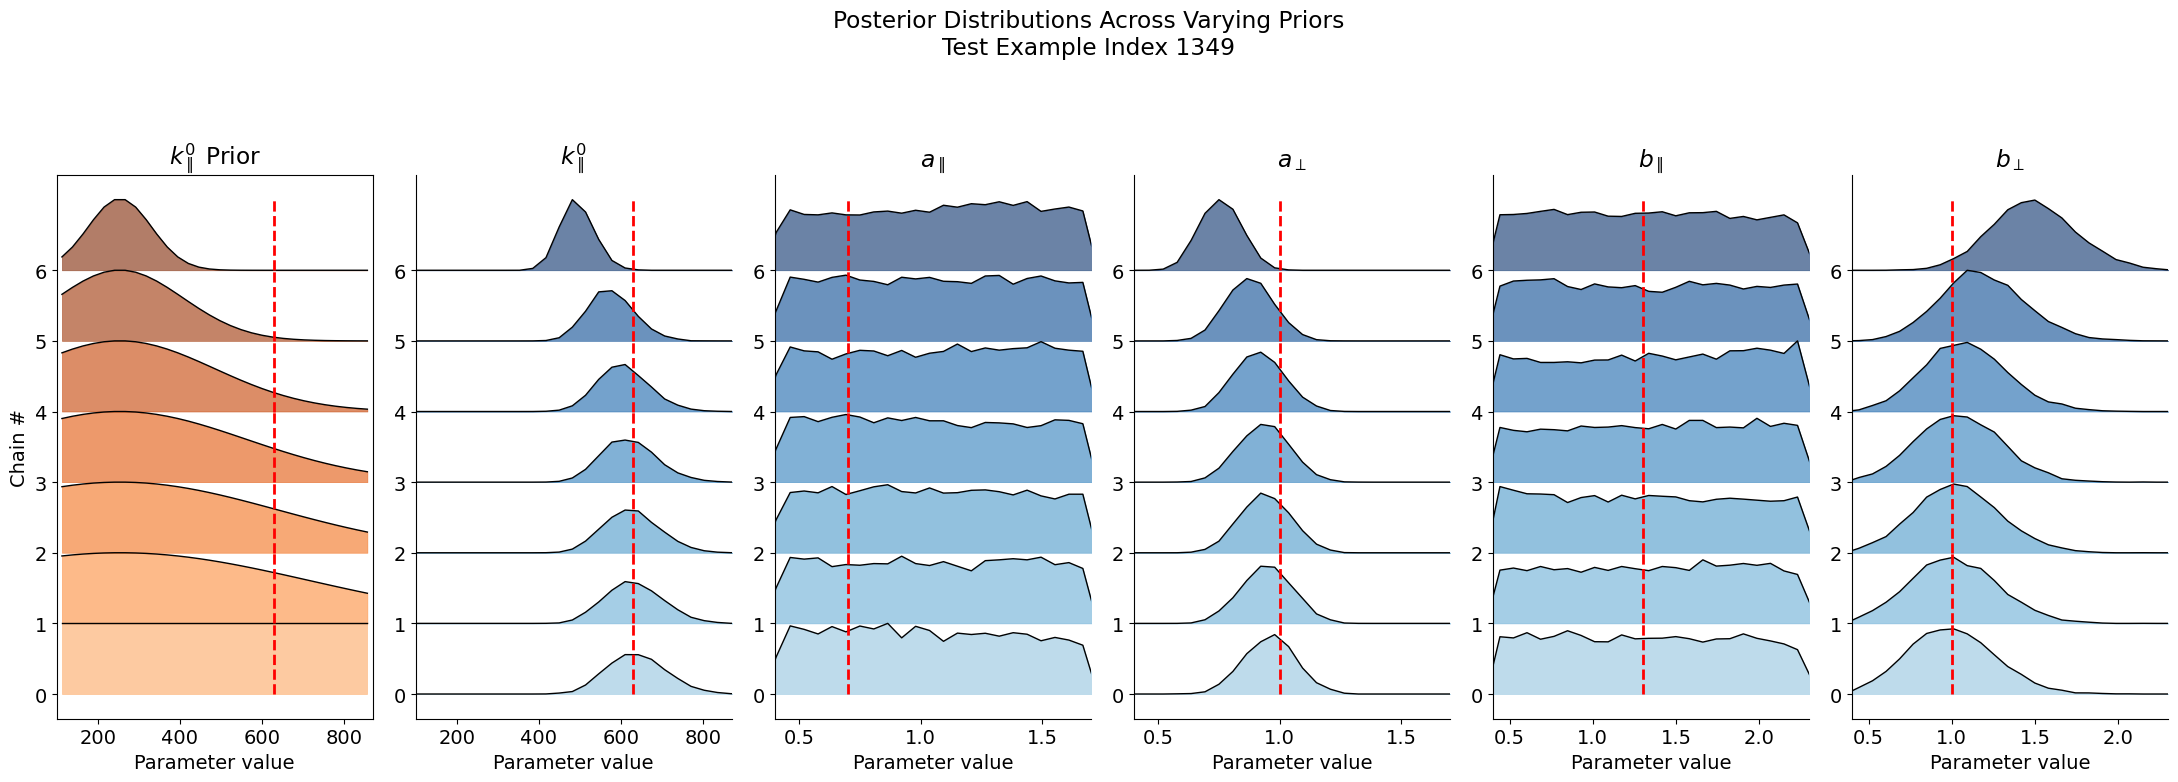

In [27]:
data_version=['d1', 'd2', 'd3', 'd4', 'd5'] 
model_version=['init1', 'init2', 'init3', 'init4', 'init5'] 
hmc_run = ['hmc1', 'hmc2', 'hmc3', 'hmc4', 'hmc5']
bootstrap=['b0', 'b1'] # 'b0' or 'b1', false or true

# Parameters (change me!)
valid_interval_indices = [2, 79, 87, 103, 104, 128, 129, 146, 170, 175, 212, 235, 263, 311, 312, 337, 346, 358, 373, 403, 423, 434, 481, 484, 496, 519, 526, 528, 531, 549, 569, 579, 613, 616, 627, 645, 660, 668, 699, 707, 715, 739, 746, 777, 810, 859, 869, 917, 953, 1003, 1023, 1054, 1063, 1093, 1116, 1140, 1141, 1161, 1206, 1218, 1238, 1249, 1267, 1273, 1277, 1279, 1311, 1315, 1349, 1354, 1375, 1394, 1407, 1414, 1432, 1464, 1475, 1477, 1540, 1551, 1589, 1648, 1695, 1761, 1776, 1781, 1846, 1908, 1914, 1949, 1981, 1998, 2035, 2042, 2056, 2127, 2145, 2160, 2188, 2194]

# Pick 1 random index to plot
np.random.seed(9)
test_index = np.random.choice(valid_interval_indices, size=5, replace=False)[3]
print(f"Randomly selected index to plot: {test_index}")

train_size_fraction = 1.0

# Define the 7 versions from least constrained (bottom) to most constrained (top)
base_version = 'v34_trial5_ppc_10000_interpolated_test_pamela_sampled_False'
hmc_versions = [
    base_version, # Uniform will be at the bottom (offset 0)
    f'prior_experiment/prior_mu02_sigma06_{base_version}',
    f'prior_experiment/prior_mu02_sigma05_{base_version}',
    f'prior_experiment/prior_mu02_sigma04_{base_version}',
    f'prior_experiment/prior_mu02_sigma03_{base_version}',
    f'prior_experiment/prior_mu02_sigma02_{base_version}',
    f'prior_experiment/prior_mu02_sigma01_{base_version}' # Most constrained at the top (offset 6)
]

make_new_file = False
output_log_file = f'../../../results/prior_experiment/{base_version}/plots/ppc_log_prob_priors.csv'
save_dir = Path(f'../../../results/prior_experiment/{base_version}/plots/priors')
save_dir.mkdir(parents=True, exist_ok=True)

if make_new_file:
    with open(output_log_file, 'w') as f:
        f.write(f"version,index,hist_#,param,train_size_fraction,-log_prob\n")
print(f"Saving to {output_log_file}? {make_new_file}")

# We will use just the first HMC initialization/model config for this test example
data_bootstrap_model_hmc_identifier = f"{data_version[0]}_{bootstrap[0]}_{model_version[0]}_{hmc_run[0]}"

# Initialize exp_name, interval, and polarity for test data
df = pd.DataFrame({
    'experiment_name': ['test_neg'],
    'interval': ['test_neg'],
    'polarity': ['neg']
})
df_int = df.iloc[0]
interval = df_int.interval
polarity = df_int.polarity
exp_name = df_int.experiment_name

# Load the samples for the chosen index across the 7 different priors
chains_data = []
for version in hmc_versions:
    results_dir = f"../../../results/{version}/{data_bootstrap_model_hmc_identifier}_{train_size_fraction}/"
    file_path = f'{results_dir}samples_{test_index}_{exp_name}_{interval}_{polarity}.csv'
    try:
        samples_df = pd.read_csv(file_path, header=None, delimiter=',')
        samples_df.columns = PARAMETERS
        chains_data.append(samples_df)
    except FileNotFoundError as e:
        print(f"File not found for version {version}: {e}")
        # Append empty df to maintain indexing if a file is missing
        chains_data.append(pd.DataFrame(columns=PARAMETERS))

# Load x_test true parameter value for that index
h5_file = '/home/linneamw/sadow_koastore/personal/linneamw/research/gcr/data/shuffled_may2025/neg/test.h5'

with h5py.File(h5_file, 'r') as h5:
    x_test_all = h5['X_minmax'][:]
    
x_test_single = x_test_all[test_index, :]
sampled_parameters_single = x_test_single[2:7]
true_parameter_values = untransform_input(sampled_parameters_single)

# Plot histograms for each parameter across the different priors
num_chains = len(hmc_versions) # 7 priors
scale = True
colors = plt.cm.Blues(np.linspace(0.4, 1.0, num_chains))
oranges = plt.cm.Oranges(np.linspace(0.4, 1.0, num_chains))

fig, axs = plt.subplots(1, 6, figsize=(22, 8), sharey=False)
plt.suptitle(f"Posterior Distributions Across Varying Priors\nTest Example Index {test_index}")

# Plot the prior on the first axis
ax = axs[0]
param_range = PARAMETERS_MAX[0] - PARAMETERS_MIN[0]
bins = np.linspace(PARAMETERS_MIN[0], PARAMETERS_MAX[0], num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Use enumerate to get both the index (k) and the color from your colors array
for k, color in enumerate(oranges):
    offset = k  # Vertical offset (0 is uniform at bottom, 6 is sigma01 at top)
    
    if k == 0:
        # Uniform prior: 1 inside the min/max bounds, 0 outside
        pdf = np.where((bin_centers >= PARAMETERS_MIN[0]) & (bin_centers <= PARAMETERS_MAX[0]), 1.0, 0.0)
    else:
        # Gaussian prior
        sigma_scaled = 0.7 - (k * 0.1) 
        mu_unscaled = 0.2 * param_range + PARAMETERS_MIN[0]
        sigma_unscaled = sigma_scaled * param_range
        
        # Calculate the Normal PDF mathematically
        pdf = np.exp(-0.5 * ((bin_centers - mu_unscaled) / sigma_unscaled)**2) / (sigma_unscaled * np.sqrt(2 * np.pi))

    # Scale the PDF so its maximum height is 1 (keeps the ridgeline neat)
    if pdf.max() > 0:
        pdf = pdf / pdf.max()

    # Filled area
    ax.fill_between(
        bin_centers,
        offset,
        pdf + offset,
        alpha=0.6,
        linewidth=0.5,
        edgecolor="black",
        color=color,
    )

    # Draw a vertical dashed line at the true parameter spanning this ridge
    ax.plot(
        [true_parameter_values[0], true_parameter_values[0]],
        [offset, offset + 1],
        color="red",
        lw=2,
        linestyle="--",
        zorder=10,
    )

    # Outline
    ax.plot(bin_centers, pdf + offset, linewidth=1.0, color="black")

    ax.set_title(f"{PARAMETERS_NAME[0]} Prior") 
    ax.set_xlim(PARAMETERS_MIN[0], PARAMETERS_MAX[0])
    ax.set_yticks(range(num_chains))
    ax.set_xlabel("Parameter value")
    ax.set_ylabel("Chain #")

offset = 0

for j, param in enumerate(PARAMETERS):
    vmin = PARAMETERS_MIN[j] - 0.2 * PARAMETERS_MIN[j]
    vmax = PARAMETERS_MAX[j] + 0.2 * PARAMETERS_MAX[j]
    param_range = PARAMETERS_MAX[j] - PARAMETERS_MIN[j]
    
    bins = np.linspace(vmin, vmax, num_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    ax = axs[j + 1]
    max_hist = 0
    log_prob_true_param = []
    
    # Get maximum histogram value across all chains for scaling
    for k, chain in enumerate(chains_data):
        if chain.empty: continue
        samples = chain[param].values
        hist, _ = np.histogram(samples, bins=bins, density=True)
        if hist.max() > max_hist:
            max_hist = hist.max()

    # Ridgeline plotting
    for k, (chain, color) in enumerate(zip(chains_data, colors)):
        offset = k  # Vertical offset (0 is uniform at bottom, 6 is sigma01 at top)

        if chain.empty: continue
        samples = chain[param].values
        hist, bin_edges = np.histogram(samples, bins=bins, density=True)

        if scale and max_hist > 0:
            hist = hist / max_hist
        
        # Filled area
        ax.fill_between(
            bin_centers,
            offset,
            hist + offset,
            alpha=0.6,
            linewidth=0.5,
            edgecolor="black",
            color=color,
        )

        # Outline
        ax.plot(bin_centers, hist + offset, linewidth=1.0, color="black")

        # True parameter value for this specific parameter (j)
        current_true_parameter = true_parameter_values[j]

        log_prob_value = histogram_log_prob(current_true_parameter, hist, bin_edges)
        log_prob_true_param.append(log_prob_value)

        # Draw a vertical dashed line at the true parameter spanning this ridge
        ax.plot(
            [current_true_parameter, current_true_parameter],
            [offset, offset + 1],
            color="red",
            lw=2,
            linestyle="--",
            zorder=10,
        )

        if make_new_file:
            with open(output_log_file, 'a') as f:
                f.write(f"{hmc_versions[k]},{test_index},{k},{param},{train_size_fraction},{-1 * log_prob_value}\n")

    ax.set_title(f"{PARAMETERS_NAME[j]}") 
    ax.set_xlim(PARAMETERS_MIN[j], PARAMETERS_MAX[j])
    ax.set_yticks(range(num_chains))
    ax.set_xlabel("Parameter value")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(save_dir / f'prior_comparison_index_{test_index}.png', dpi=300)
plt.savefig(save_dir / f'prior_comparison_index_{test_index}.pdf')
plt.show()
plt.close()

## Split uncertainty experiment

Interval 20150124-20150219 corresponds to index 48 for neg polarity in AMS02_H-PRL2021.


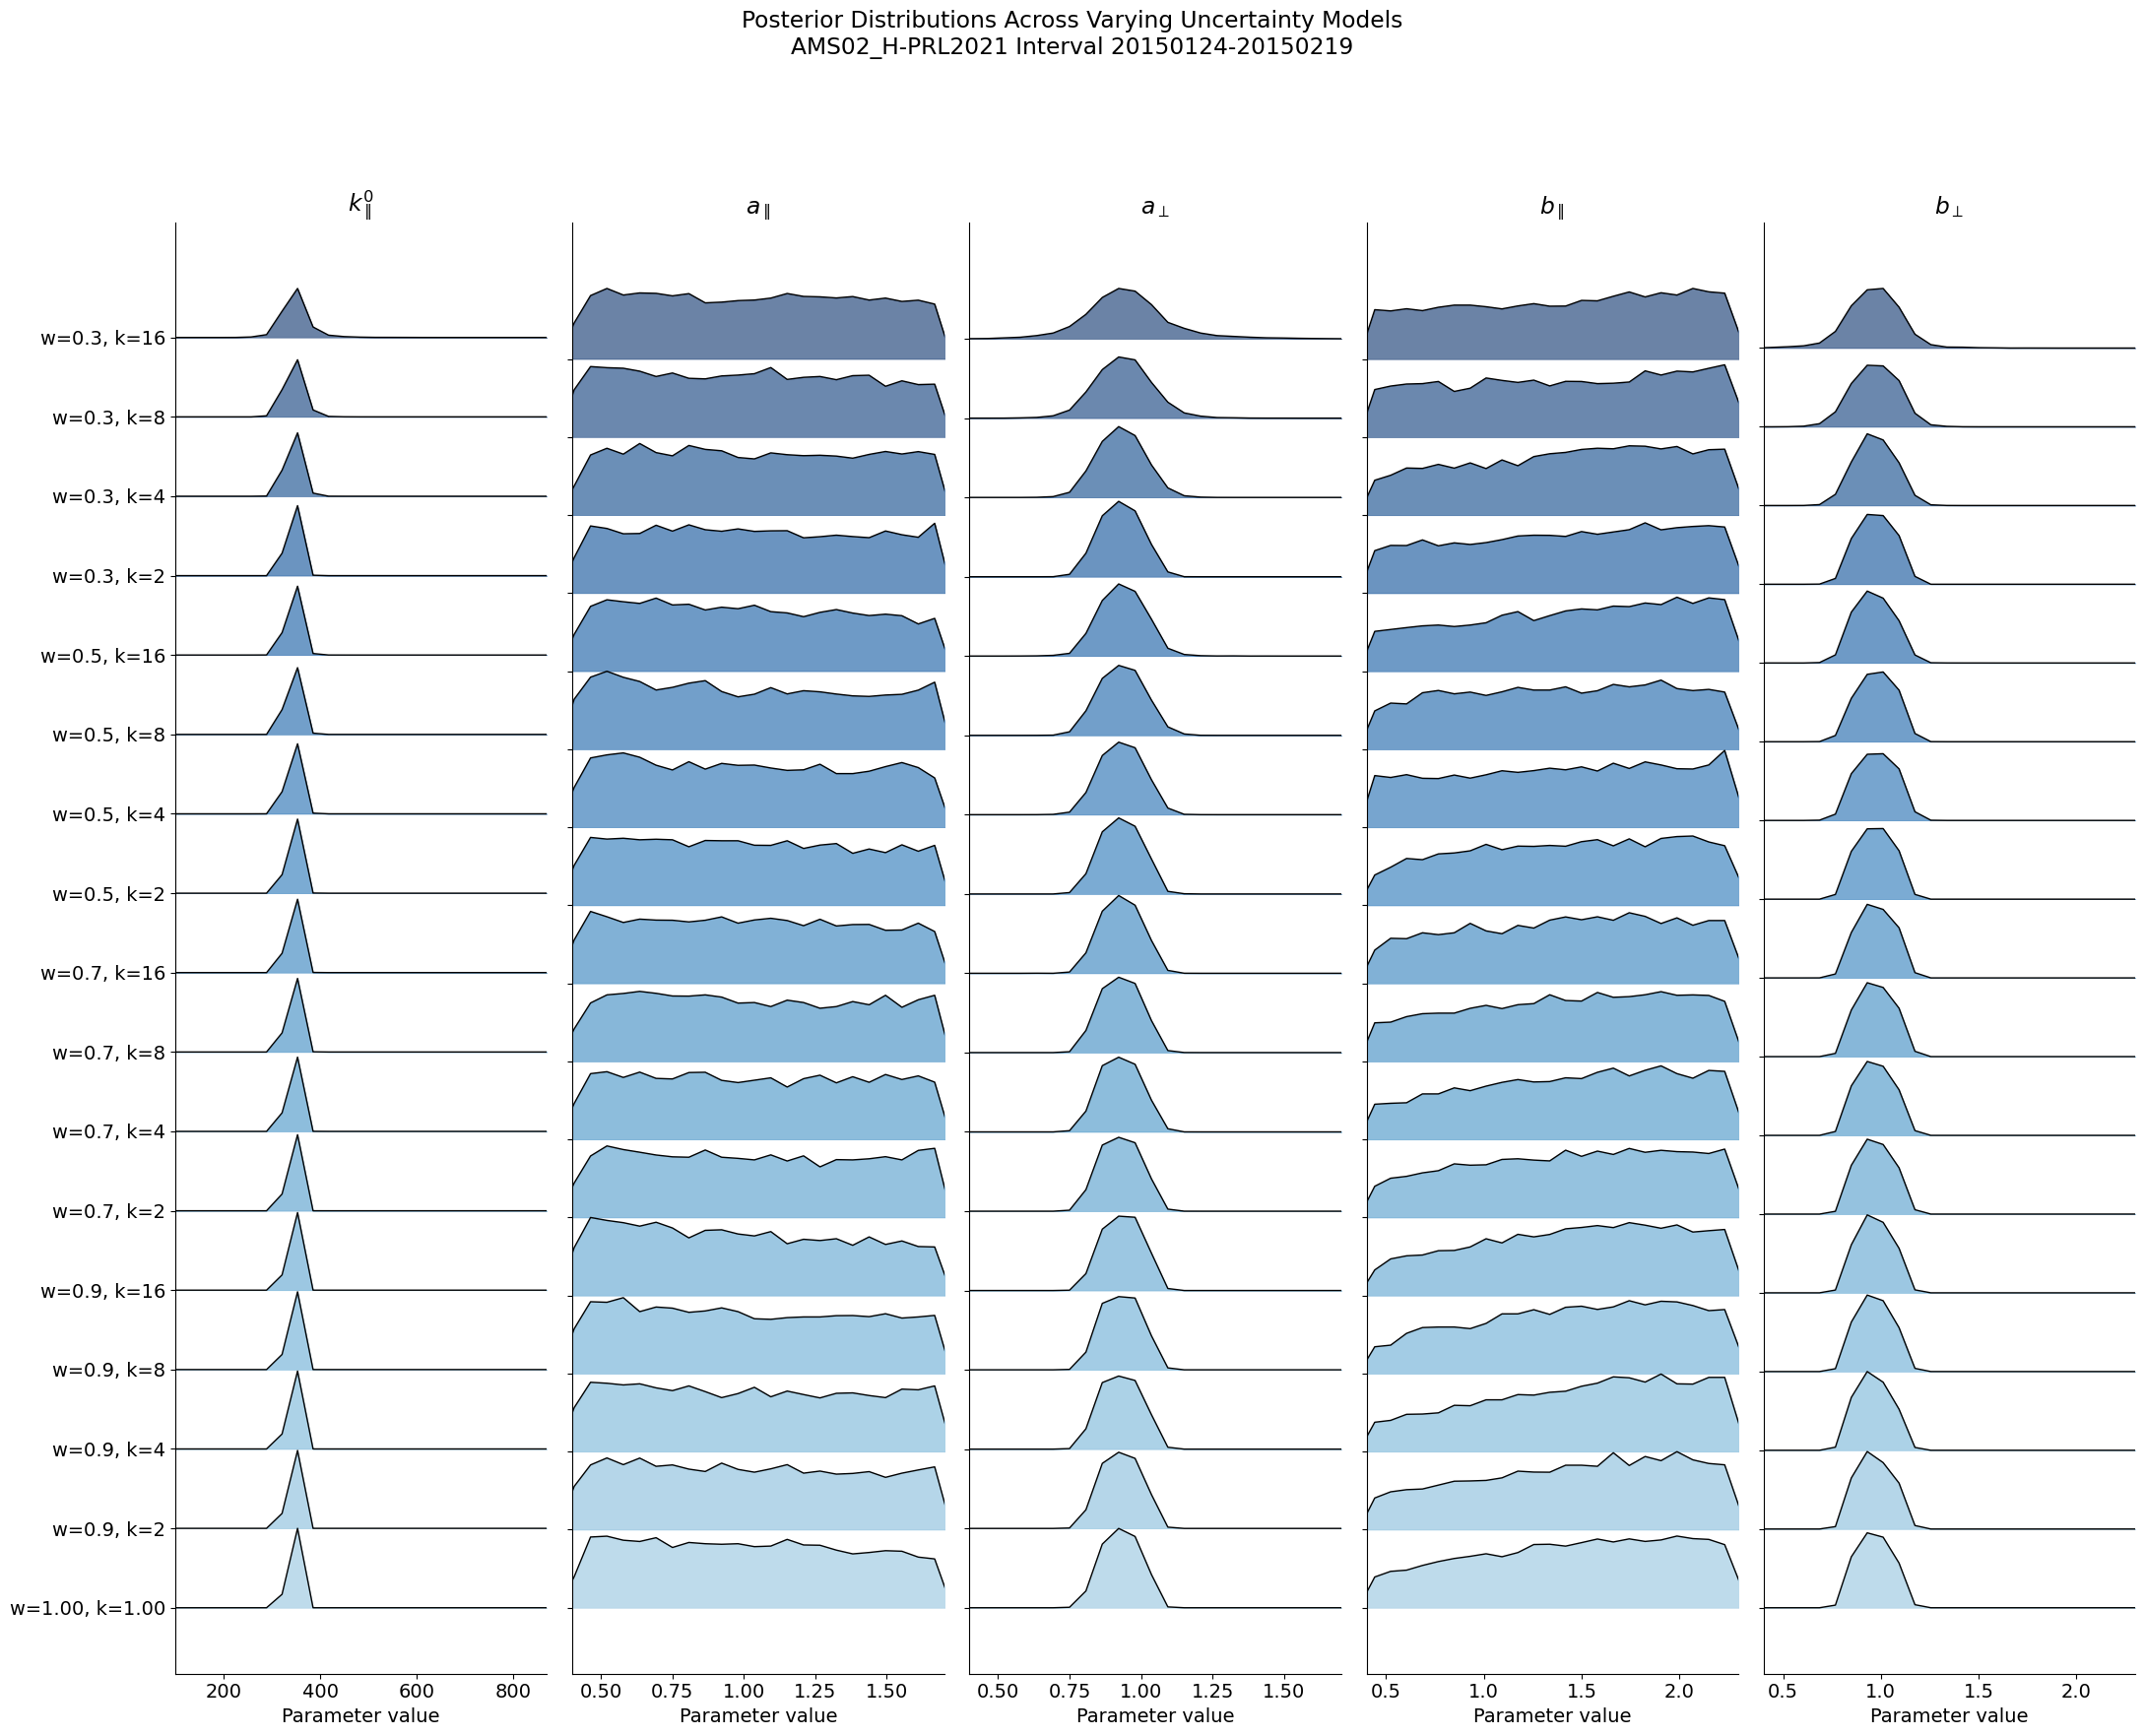

In [28]:
data_version=['d1', 'd2', 'd3', 'd4', 'd5'] 
model_version=['init1', 'init2', 'init3', 'init4', 'init5'] 
hmc_run = ['hmc1', 'hmc2', 'hmc3', 'hmc4', 'hmc5']
bootstrap=['b0', 'b1'] # 'b0' or 'b1', false or true

train_size_fraction = 1.0

# Define the multiple versions from least constrained (bottom) to most constrained (top)
base_version = 'split_uncertainty_experiment/split_uncertainty_false_w1_k1_v34_trial5_interpolated_2023'
split_uncertainty_base_version = 'v34_trial5_interpolated_2023'
hmc_versions = [
    base_version, # Regular combined uncertainty will be at the bottom
]
w_k_list = ['w=1.00, k=1.00']

for w in [0.9, 0.7, 0.5, 0.3]:
    for k in [2, 4, 8, 16]:
        hmc_versions.append(f'split_uncertainty_experiment/split_uncertainty_w{w}_k{k}_{split_uncertainty_base_version}')
        w_k_list.append(f'w={w:.1f}, k={k:.0f}')

make_new_file = False
output_log_file = f'../../../results/{base_version}/plots/split_uncertainty_experiment.csv'
save_dir = Path(f'../../../results/{base_version}/plots/split_uncertainty')
save_dir.mkdir(parents=True, exist_ok=True)

# We will use just the first HMC initialization/model config for this test example
data_bootstrap_model_hmc_identifier = f"{data_version[0]}_{bootstrap[0]}_{model_version[0]}_{hmc_run[0]}"

# Get interval corresponding to one in paper
test_index = 48 # 48 is the AMS-02 interval index in the paper
df = index_mcmc_runs(file_version='2023')
df_int = df.iloc[test_index:test_index+1].copy(deep=True)
interval = df_int.interval.iloc[0]
polarity = df_int.polarity.iloc[0]
exp_name = df_int.experiment_name.iloc[0]
print(f"Interval {interval} corresponds to index {test_index} for {polarity} polarity in {exp_name}.")
df_int.head()

# Load the samples for the chosen index across the 7 different priors
chains_data = []
for version in hmc_versions:
    results_dir = f"../../../results/{version}/{data_bootstrap_model_hmc_identifier}_{train_size_fraction}/"
    file_path = f'{results_dir}samples_{test_index}_{exp_name}_{interval}_{polarity}.csv'
    try:
        samples_df = pd.read_csv(file_path, header=None, delimiter=',')
        samples_df.columns = PARAMETERS
        chains_data.append(samples_df)
    except FileNotFoundError as e:
        print(f"File not found for version {version}: {e}")
        # Append empty df to maintain indexing if a file is missing
        chains_data.append(pd.DataFrame(columns=PARAMETERS))

# Plot histograms for each parameter across the different priors
num_chains = len(hmc_versions) 
scale = True
colors = plt.cm.Blues(np.linspace(0.4, 1.0, num_chains))

fig, axs = plt.subplots(1, 5, figsize=(22, 18), sharey=False)
plt.suptitle(f"Posterior Distributions Across Varying Uncertainty Models\n{exp_name} Interval {interval}")

offset = 0

for j, param in enumerate(PARAMETERS):
    vmin = PARAMETERS_MIN[j] - 0.2 * PARAMETERS_MIN[j]
    vmax = PARAMETERS_MAX[j] + 0.2 * PARAMETERS_MAX[j]
    param_range = PARAMETERS_MAX[j] - PARAMETERS_MIN[j]
    
    bins = np.linspace(vmin, vmax, num_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    ax = axs[j]
    max_hist = 0
    log_prob_true_param = []
    
    # Get maximum histogram value across all chains for scaling
    for k, chain in enumerate(chains_data):
        if chain.empty: continue
        samples = chain[param].values
        hist, _ = np.histogram(samples, bins=bins, density=True)
        if hist.max() > max_hist:
            max_hist = hist.max()

    # Ridgeline plotting
    for k, (chain, color) in enumerate(zip(chains_data, colors)):
        offset = k  # Vertical offset (0 is uniform at bottom, 6 is sigma01 at top)

        if chain.empty: continue
        samples = chain[param].values
        hist, bin_edges = np.histogram(samples, bins=bins, density=True)

        if scale and max_hist > 0:
            hist = hist / max_hist
        
        # Filled area
        ax.fill_between(
            bin_centers,
            offset,
            hist + offset,
            alpha=0.6,
            linewidth=0.5,
            edgecolor="black",
            color=color,
        )

        # Outline
        ax.plot(bin_centers, hist + offset, linewidth=1.0, color="black")

    ax.set_title(f"{PARAMETERS_NAME[j]}") 
    ax.set_xlim(PARAMETERS_MIN[j], PARAMETERS_MAX[j])

    # Set y-tick labels
    if j == 0:
        # First set the numeric positions
        ax.set_yticks(range(len(w_k_list)))
        # Then set the corresponding string labels
        ax.set_yticklabels(w_k_list)
    else:
        # For other plots, just set the numeric positions
        ax.set_yticks(range(len(w_k_list)))
        ax.set_yticklabels([])

    ax.set_xlabel("Parameter value")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(save_dir / f'uncertainty_model_comparison_index_{test_index}.png', dpi=300)
plt.savefig(save_dir / f'uncertainty_model_comparison_index_{test_index}.pdf')
plt.show()
plt.close()

['w=1.00, k=1.00', 'w=0.99, k=1.5', 'w=0.99, k=2.0', 'w=0.99, k=4.0', 'w=0.95, k=1.5', 'w=0.95, k=2.0', 'w=0.95, k=4.0', 'w=0.90, k=1.5', 'w=0.90, k=2.0', 'w=0.90, k=4.0', 'w=0.90, k=8.0', 'w=0.90, k=16.0', 'w=0.70, k=2.0', 'w=0.70, k=4.0', 'w=0.70, k=8.0', 'w=0.70, k=16.0', 'w=0.50, k=2.0', 'w=0.50, k=4.0', 'w=0.50, k=8.0', 'w=0.50, k=16.0', 'w=0.30, k=2.0', 'w=0.30, k=4.0', 'w=0.30, k=8.0', 'w=0.30, k=16.0']
Interval 20150124-20150219 corresponds to index 48 for neg polarity in AMS02_H-PRL2021.
Parsed w and k values for heatmap axes:
w=1.00, k=1.00 -> w: 1.0, k: 1.0
w=0.99, k=1.5 -> w: 0.99, k: 1.5
w=0.99, k=2.0 -> w: 0.99, k: 2.0
w=0.99, k=4.0 -> w: 0.99, k: 4.0
w=0.95, k=1.5 -> w: 0.95, k: 1.5
w=0.95, k=2.0 -> w: 0.95, k: 2.0
w=0.95, k=4.0 -> w: 0.95, k: 4.0
w=0.90, k=1.5 -> w: 0.9, k: 1.5
w=0.90, k=2.0 -> w: 0.9, k: 2.0
w=0.90, k=4.0 -> w: 0.9, k: 4.0
w=0.90, k=8.0 -> w: 0.9, k: 8.0
w=0.90, k=16.0 -> w: 0.9, k: 16.0
w=0.70, k=2.0 -> w: 0.7, k: 2.0
w=0.70, k=4.0 -> w: 0.7, k: 4.0
w

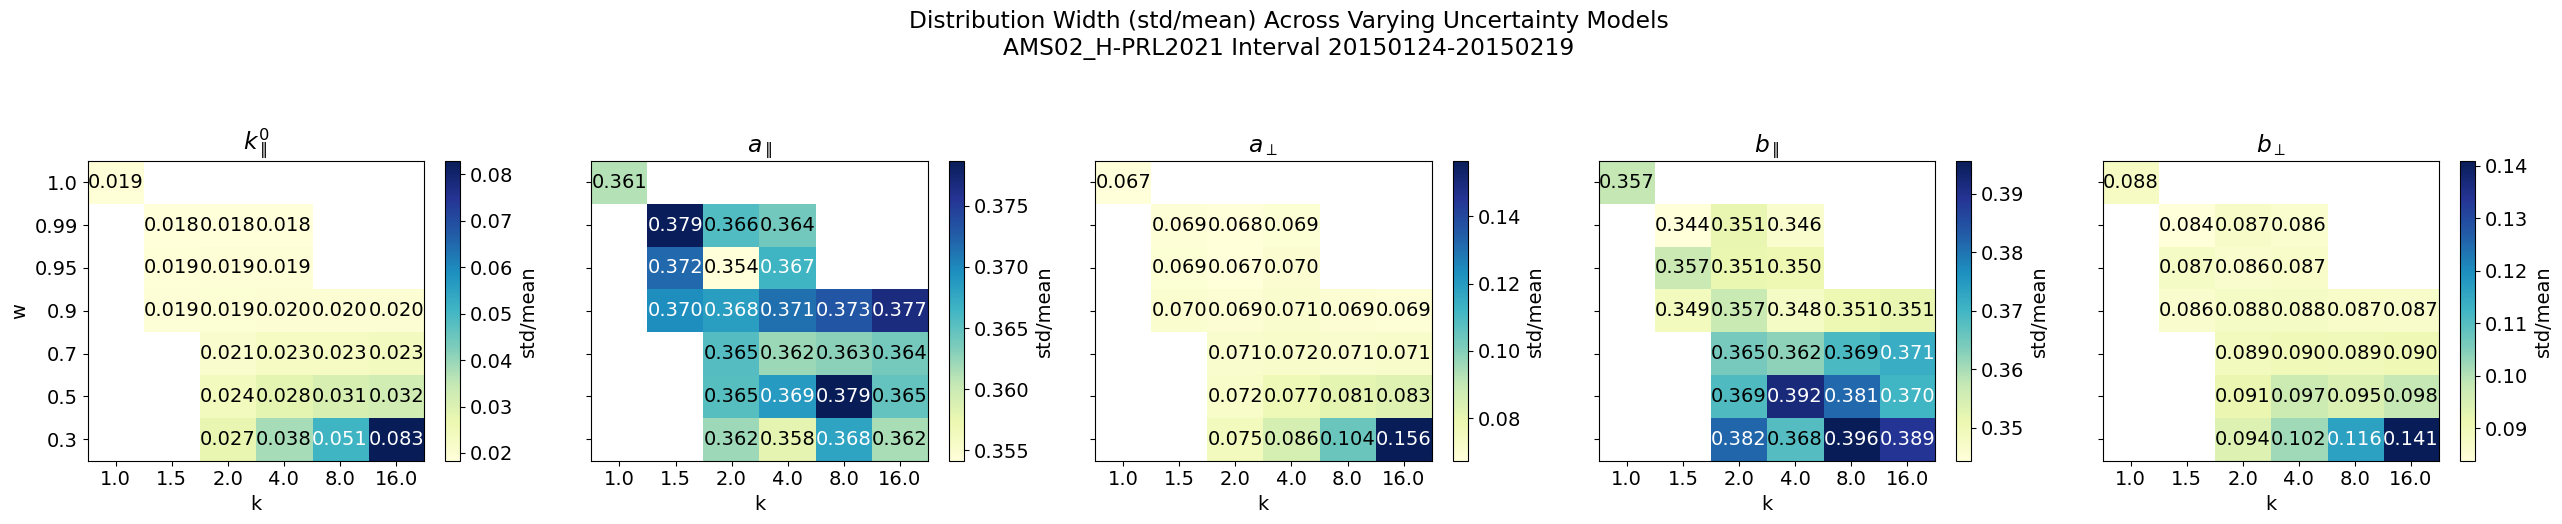

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- Keep your existing setup code ---
data_version=['d1', 'd2', 'd3', 'd4', 'd5'] 
model_version=['init1', 'init2', 'init3', 'init4', 'init5'] 
hmc_run = ['hmc1', 'hmc2', 'hmc3', 'hmc4', 'hmc5']
bootstrap=['b0', 'b1'] # 'b0' or 'b1', false or true

train_size_fraction = 1.0

# Define the multiple versions from least constrained (bottom) to most constrained (top)
base_version = 'split_uncertainty_experiment/split_uncertainty_false_w1_k1_v34_trial5_interpolated_2023'
split_uncertainty_base_version = 'v34_trial5_interpolated_2023'
hmc_versions = [
    base_version, # Regular combined uncertainty will be at the bottom
]
w_k_list = ['w=1.00, k=1.00']

for w in [0.99, 0.95, 0.9, 0.7, 0.5, 0.3]:
    for k in [1.5, 2, 4, 8, 16]:
        if w > 0.9 and k > 4:
            continue
        elif w < 0.9 and k == 1.5:
            continue
        else:
            hmc_versions.append(f'split_uncertainty_experiment/split_uncertainty_w{w}_k{k}_{split_uncertainty_base_version}')
            w_k_list.append(f'w={w:.2f}, k={k:.1f}')

print(w_k_list)

make_new_file = False
output_log_file = f'../../../results/{base_version}/plots/split_uncertainty_experiment.csv'
save_dir = Path(f'../../../results/{base_version}/plots/split_uncertainty')
save_dir.mkdir(parents=True, exist_ok=True)

# We will use just the first HMC initialization/model config for this test example
data_bootstrap_model_hmc_identifier = f"{data_version[0]}_{bootstrap[0]}_{model_version[0]}_{hmc_run[0]}"

# Get interval corresponding to one in paper
test_index = 48 # 48 is the AMS-02 interval index in the paper
df = index_mcmc_runs(file_version='2023')
df_int = df.iloc[test_index:test_index+1].copy(deep=True)
interval = df_int.interval.iloc[0]
polarity = df_int.polarity.iloc[0]
exp_name = df_int.experiment_name.iloc[0]
print(f"Interval {interval} corresponds to index {test_index} for {polarity} polarity in {exp_name}.")

# Load the samples for the chosen index across the different priors
chains_data = []
for version in hmc_versions:
    results_dir = f"../../../results/{version}/{data_bootstrap_model_hmc_identifier}_{train_size_fraction}/"
    file_path = f'{results_dir}samples_{test_index}_{exp_name}_{interval}_{polarity}.csv'
    try:
        samples_df = pd.read_csv(file_path, header=None, delimiter=',')
        samples_df.columns = PARAMETERS
        chains_data.append(samples_df)
    except FileNotFoundError as e:
        print(f"File not found for version {version}: {e}")
        # Append empty df to maintain indexing if a file is missing
        chains_data.append(pd.DataFrame(columns=PARAMETERS))

# --- PURE MATPLOTLIB HEATMAP PLOTTING CODE ---

# 1. Parse w and k values from the w_k_list so we can use them as matrix coordinates
parsed_wk = []
for wk_str in w_k_list:
    match = re.search(r"w=([0-9.]+),\s*k=([0-9.]+)", wk_str)
    if match:
        w_val = round(float(match.group(1)), 2)
        k_val = round(float(match.group(2)), 2)
        parsed_wk.append((w_val, k_val))
    else:
        parsed_wk.append((None, None))

print("Parsed w and k values for heatmap axes:")
for wk_str, (w_val, k_val) in zip(w_k_list, parsed_wk):
    print(f"{wk_str} -> w: {w_val}, k: {k_val}")

# 2. Compute std/mean width for each parameter and format it into records
heatmap_data = {param: [] for param in PARAMETERS}

for k_idx, (chain, (w_val, k_val)) in enumerate(zip(chains_data, parsed_wk)):
    if chain.empty or w_val is None: 
        continue
        
    for param in PARAMETERS:
        samples = chain[param].values
        mean_val = np.mean(samples)
        std_val = np.std(samples)
        
        # Absolute mean used to safely handle parameters that could center around 0
        width = std_val / np.abs(mean_val) if mean_val != 0 else np.nan
        
        heatmap_data[param].append({
            'w': w_val,
            'k': k_val,
            'width': width
        })

# 3. Plot the Heatmaps using Matplotlib
# You might want to slightly increase the width from 24 to 26 or 28 if the individual colorbars squeeze the heatmaps too much
fig, axs = plt.subplots(1, len(PARAMETERS), figsize=(26, 5))
plt.suptitle(f"Distribution Width (std/mean) Across Varying Uncertainty Models\n{exp_name} Interval {interval}", y=1.05)

for j, param in enumerate(PARAMETERS):
    ax = axs[j]
    
    # Convert records to DataFrame
    df_param = pd.DataFrame(heatmap_data[param])
    if df_param.empty:
        continue
        
    # Pivot to create a 2D grid: rows=w, columns=k
    pivot_df = df_param.pivot(index='w', columns='k', values='width')
    pivot_df = pivot_df.sort_index(ascending=False) 
    
    # Draw heatmap using imshow
    im = ax.imshow(pivot_df.values, cmap="YlGnBu", aspect="auto")
    
    # Set ticks and labels manually
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.columns)
    
    # Only show y-axis labels on the far left plot
    if j == 0:
        ax.set_yticklabels(pivot_df.index)
        ax.set_ylabel("w")
    else:
        ax.set_yticklabels([])
    
    # Annotate the cells with the numeric values
    # Calculate a rough threshold to switch text color from black to white for readability
    threshold = (np.nanmax(pivot_df.values) + np.nanmin(pivot_df.values)) / 2.0 if not np.isnan(np.nanmax(pivot_df.values)) and not np.isnan(np.nanmin(pivot_df.values)) else 0
    
    for row in range(len(pivot_df.index)):
        for col in range(len(pivot_df.columns)):
            val = pivot_df.values[row, col]
            if not np.isnan(val):
                # If value is high (darker background), make text white
                text_color = "white" if val > threshold else "black"
                ax.text(col, row, f"{val:.3f}", ha="center", va="center", color=text_color)
    
    # Add a colorbar to EVERY plot
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('std/mean')
    
    ax.set_title(f"{PARAMETERS_NAME[j]}")
    ax.set_xlabel("k")

plt.tight_layout()
plt.savefig(save_dir / f'uncertainty_model_heatmap_index_{test_index}.png', dpi=300, bbox_inches='tight')
plt.savefig(save_dir / f'uncertainty_model_heatmap_index_{test_index}.pdf', bbox_inches='tight')
plt.show()
plt.close()